# 1. Import libraries

In [16]:
import os
import sys
import pandas as pd
import numpy as np

import librosa
import librosa.display
import IPython
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
import IPython.display as ipd
from IPython.display import Audio
import keras
from keras.models import Sequential, Model
from keras.layers import (
    Dense, Embedding, LSTM, GRU, BatchNormalization,
    Input, Flatten, Dropout, Activation,
    Conv1D, MaxPooling1D, AveragePooling1D,
    TextVectorization  
)
from keras.utils import pad_sequences, to_categorical
from keras.callbacks import ModelCheckpoint
from keras.optimizers import SGD

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import tensorflow as tf 
print ("Done")

Done


# 2. Data Loading and Analysis

In [2]:
df = pd.read_csv("/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv")
print(f"Data Shape : {df.shape}")
df.head(5)

Data Shape : (9990, 60)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [13]:
df = df.drop(labels='filename', axis=1)

# 3. Audio Visualization

In [4]:
audio = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original/classical/classical.00001.wav"
# loading the audio file
data, sr = librosa.load(audio) # sr : sampling rate
print(type(data), type(sr), data.shape)

<class 'numpy.ndarray'> <class 'int'> (661794,)


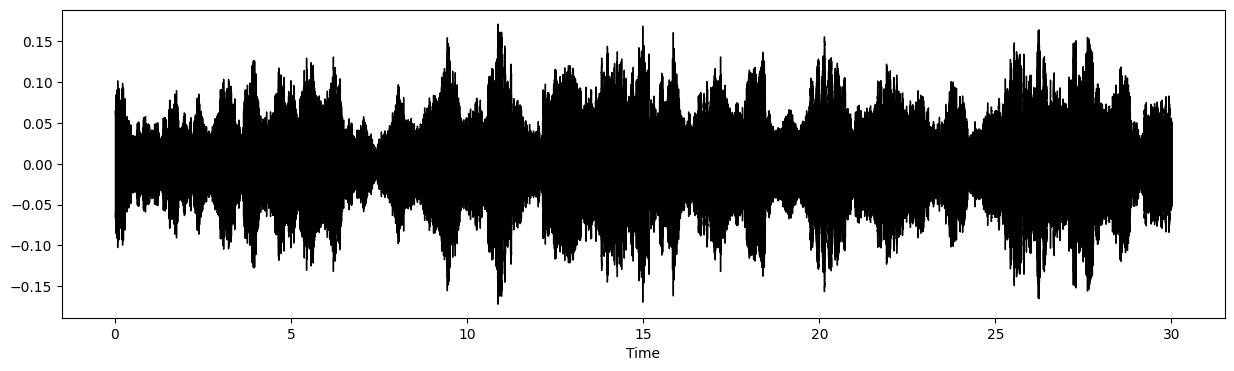

In [5]:
librosa.load(audio, sr=45600)
IPython.display.Audio(data, rate=sr)

# plotting the waveform
plt.figure(figsize=(15,4))
librosa.display.waveshow(data, color="Black")
plt.show()

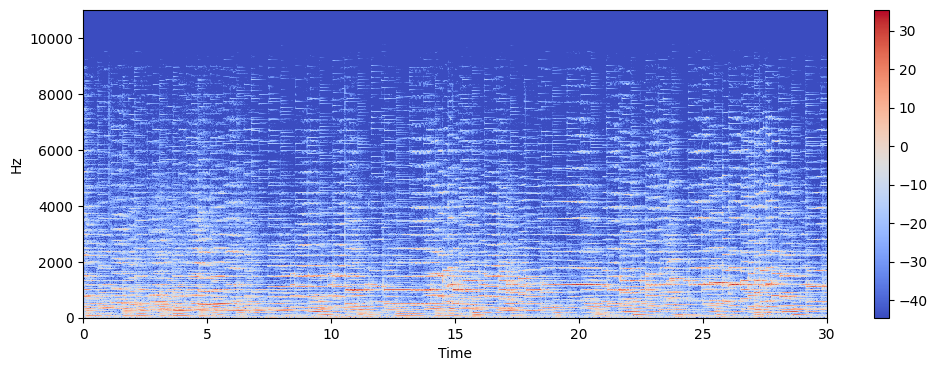

In [6]:
stft = librosa.stft(data)
stft_db = librosa.amplitude_to_db(abs(stft))
plt.figure(figsize=(12,4))
librosa.display.specshow(stft_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()

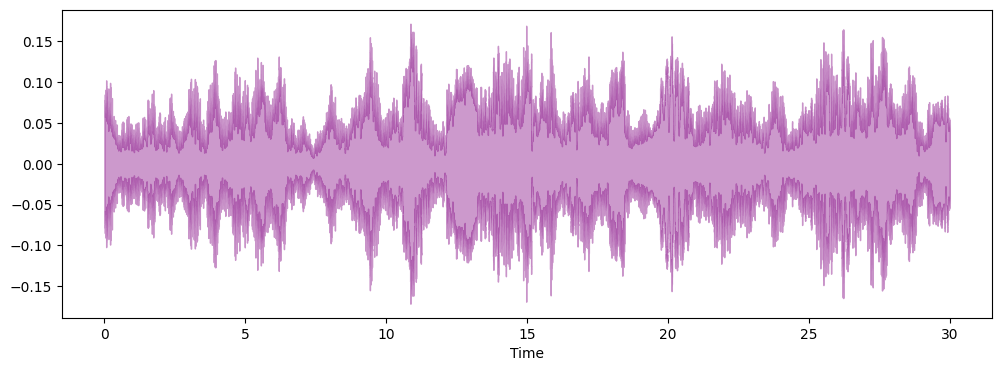

In [7]:
#computing the rolloff frequency for each frame in a signal
spectral_rolloff = librosa.feature.spectral_rolloff(y=data+0.01, sr=sr)[0]
plt.figure(figsize=(12,4))
librosa.display.waveshow(data, sr=sr, alpha=0.4, color='Purple')

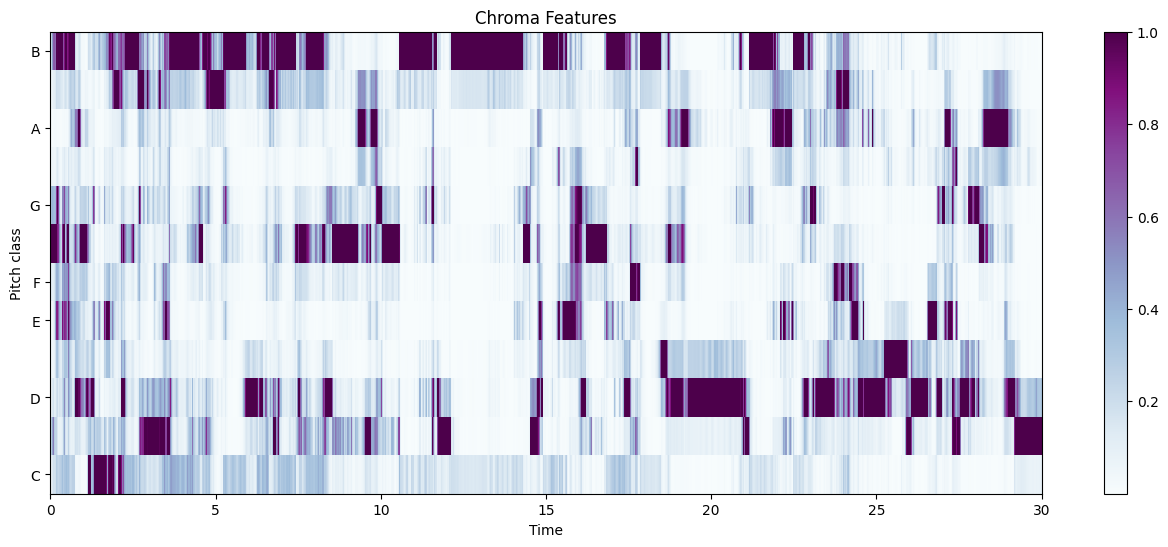

In [8]:
import librosa.display as lplt
#Chroma feature or chromagram closely relates to the twelve different pitch classes.
#Chroma features capture harmonic & melodic characteristics of music while being robust to changes.
chroma = librosa.feature.chroma_stft(y=data, sr=sr)
plt.figure(figsize=(16,6))
lplt.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', cmap='BuPu')
plt.colorbar()
plt.title("Chroma Features")
plt.show()

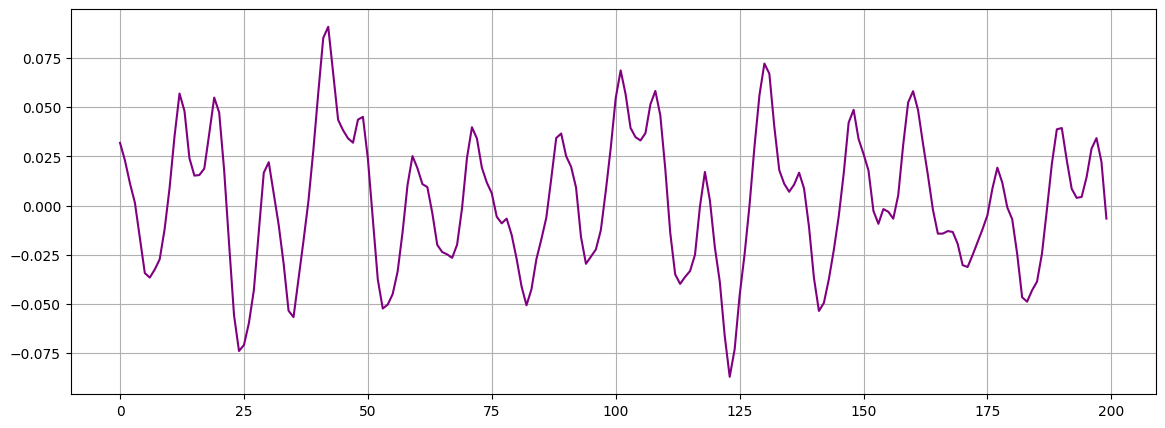

In [9]:
start = 1000
end = 1200
plt.figure(figsize=(14,5))
plt.plot(data[start:end], color='Purple')
plt.grid()

# 4. Extracting and Scaling the features

In [10]:
class_list = df.iloc[:, -1]
convertor = LabelEncoder()

y = convertor.fit_transform(class_list)
y

array([0, 0, 0, ..., 9, 9, 9], shape=(9990,))

In [14]:
print(df.iloc[:, :-1])

      length  chroma_stft_mean  chroma_stft_var  rms_mean   rms_var  \
0      66149          0.335406         0.091048  0.130405  0.003521   
1      66149          0.343065         0.086147  0.112699  0.001450   
2      66149          0.346815         0.092243  0.132003  0.004620   
3      66149          0.363639         0.086856  0.132565  0.002448   
4      66149          0.335579         0.088129  0.143289  0.001701   
...      ...               ...              ...       ...       ...   
9985   66149          0.349126         0.080515  0.050019  0.000097   
9986   66149          0.372564         0.082626  0.057897  0.000088   
9987   66149          0.347481         0.089019  0.052403  0.000701   
9988   66149          0.387527         0.084815  0.066430  0.000320   
9989   66149          0.369293         0.086759  0.050524  0.000067   

      spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  \
0                1773.065032          167541.630869              19

In [15]:
# standardize features
fit = StandardScaler()
X = fit.fit_transform(np.array(df.iloc[:, :-1], dtype=float))

# 5. Train test split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
print(f"X_train size : {len(X_train)}")
print(f"X_test size : {len(X_test)}")
print(f"y_train size : {len(y_train)}")
print(f"y_test size : {len(y_test)}")

X_train size : 6693
X_test size : 3297
y_train size : 6693
y_test size : 3297


In [20]:
def train_model(model, epochs, optimizer):
    batch_size = 128
    model.compile(
        optimizer=optimizer, 
        loss='spare_categorical_crossentropy',
        metrics = 'accuracy'    
    )
    return model.fit(
        X_train, 
        y_train, 
        validation_data=(X_test, y_test), 
        epochs=epochs,
        batch_size=batch_size
    )

#Plotting the curves
def plotValidate(history):
    print("Validation Accuracy",max(history.history["val_accuracy"]))
    pd.DataFrame(history.history).plot(figsize=(12,6))
    plt.show()

<Axes: >

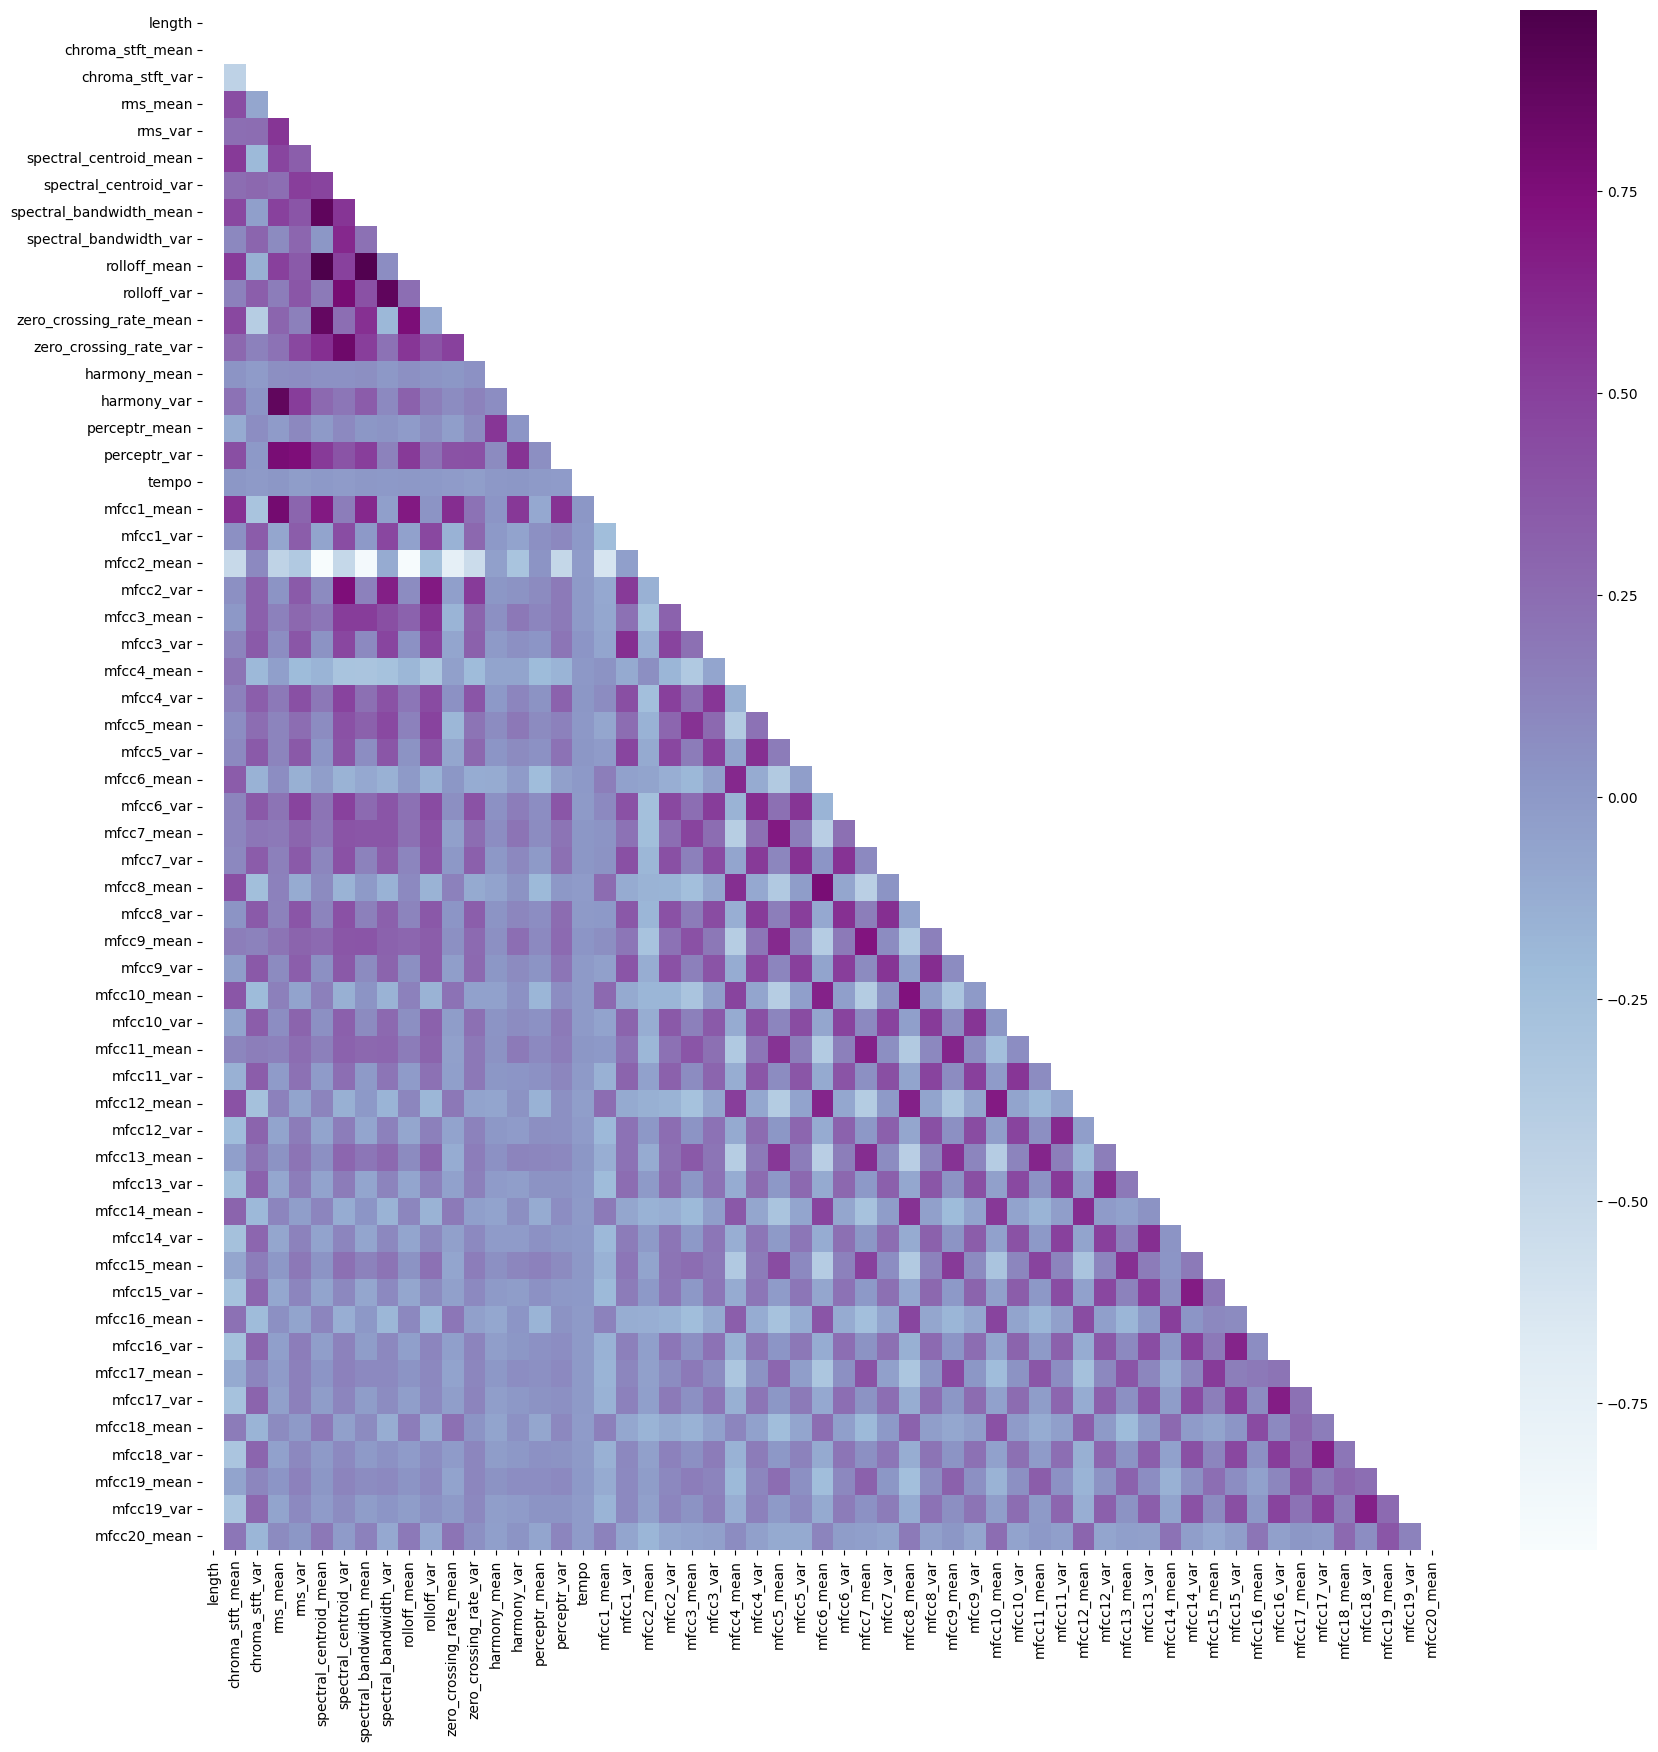

In [25]:
df = df.iloc[:, :-1] # excludes the last column
#correlation
corr = df.corr()
#Creation of a mask for the heatmap
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
plt.subplots(figsize=(20, 20))
sns.heatmap(corr, mask=mask, cmap="BuPu")

# 6. Train **XGBOOST**

In [28]:
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe

model = XGBClassifier(n_estimators=1000)
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [31]:
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
target_names = sorted(set(y))

print(f'Training accuracy: {accuracy_score(y_train,y_pred_train)}')
print(f'Training:\n {classification_report(y_train, y_pred_train, labels=target_names)}')
print(f'Testing accuracy: {accuracy_score(y_test,y_pred_test)}')
print(f'Testing:\n {classification_report(y_test, y_pred_test, labels=target_names)}')

Training accuracy: 0.9991035410129987
Training:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       682
           1       1.00      1.00      1.00       658
           2       1.00      1.00      1.00       655
           3       1.00      1.00      1.00       666
           4       1.00      1.00      1.00       654
           5       1.00      1.00      1.00       692
           6       0.99      1.00      1.00       689
           7       1.00      1.00      1.00       655
           8       1.00      1.00      1.00       682
           9       1.00      0.99      1.00       660

    accuracy                           1.00      6693
   macro avg       1.00      1.00      1.00      6693
weighted avg       1.00      1.00      1.00      6693

Testing accuracy: 0.8941461935092508
Testing:
               precision    recall  f1-score   support

           0       0.87      0.90      0.89       318
           1       0.93      0.96   

<Axes: >

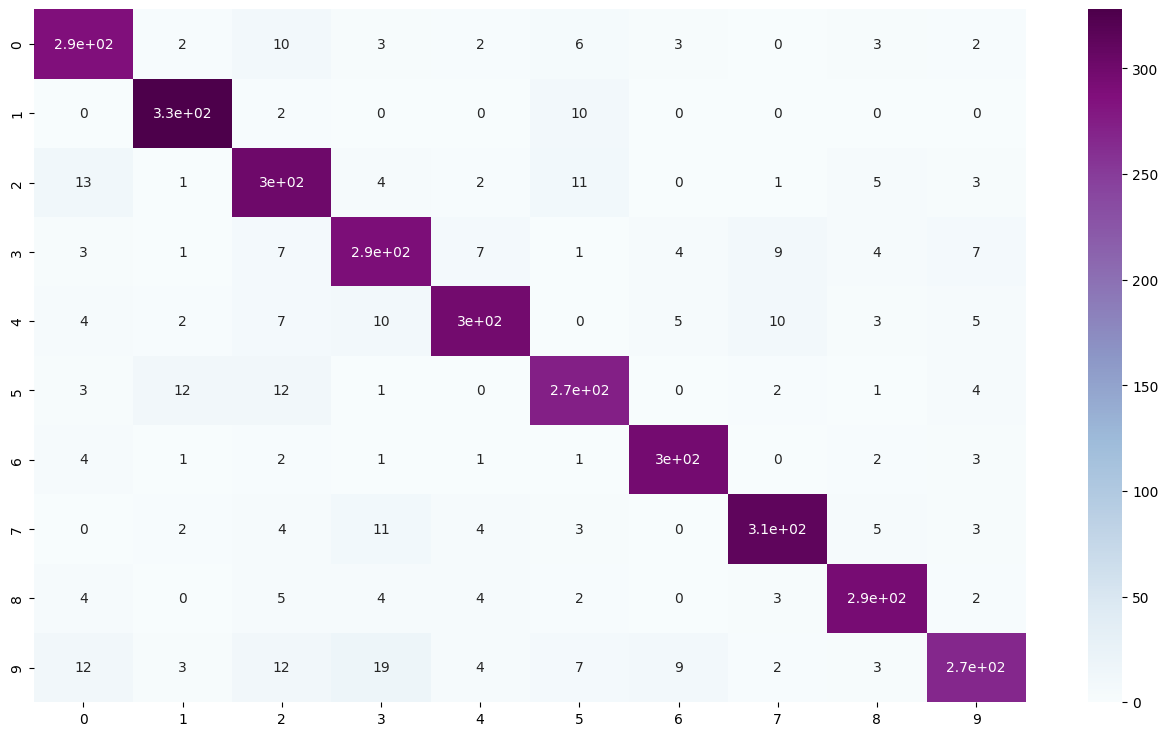

In [32]:
#Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize = (16, 9))
sns.heatmap(conf_mat,cmap="BuPu", annot=True, xticklabels = target_names, yticklabels = target_names )